In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [3]:
data = pd.read_csv("Ice Cream.csv")
print("\nFirst 5 rows of the dataset:")
print(data.head())


First 5 rows of the dataset:
   Temperature  Revenue
0         24.6      535
1         26.1      626
2         27.8      661
3         20.6      488
4         11.6      317


In [4]:
print("\nDataset Summary:")
print(data.describe())



Dataset Summary:
       Temperature      Revenue
count   500.000000   500.000000
mean     22.281600   522.058000
std       8.097597   175.410399
min       0.000000    10.000000
25%      17.175000   406.000000
50%      22.400000   530.000000
75%      27.800000   643.000000
max      45.000000  1000.000000


In [5]:
print("\nMissing Values:")
print(data.isnull().sum())



Missing Values:
Temperature    0
Revenue        0
dtype: int64


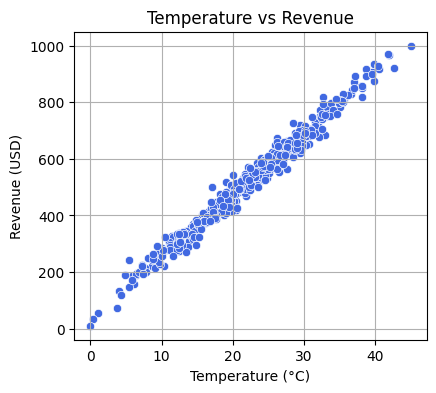

In [6]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.scatterplot(x='Temperature', y='Revenue', data=data, color='royalblue')
plt.title('Temperature vs Revenue')
plt.xlabel('Temperature (°C)')
plt.ylabel('Revenue (USD)')
plt.grid(True)


Text(0.5, 1.0, 'Correlation Heatmap')

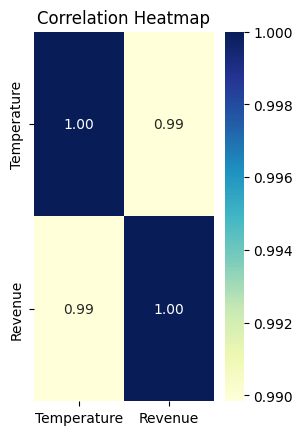

In [7]:
plt.subplot(1, 2, 2)
sns.heatmap(data.corr(), annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Correlation Heatmap')


In [8]:
plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

In [9]:
X = data[['Temperature']]
y = data['Revenue']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [12]:
dt = DecisionTreeRegressor(random_state=42, max_depth=3)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [13]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Evaluation:")
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("R^2 Score:", r2_score(y_true, y_pred))


In [14]:
evaluate_model("Linear Regression", y_test, y_pred_lr)
evaluate_model("Decision Tree Regressor", y_test, y_pred_dt)


Linear Regression Evaluation:
RMSE: 25.543958747446354
MAE: 19.195652579103704
R^2 Score: 0.9771509516333023

Decision Tree Regressor Evaluation:
RMSE: 43.182613477619476
MAE: 34.26647536883211
R^2 Score: 0.934700545304701


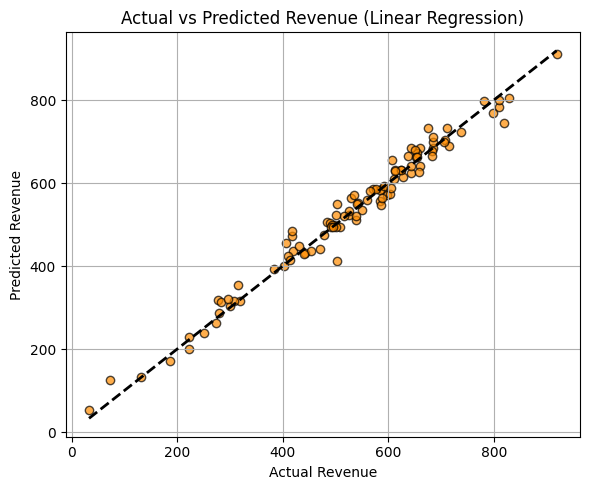

In [15]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_lr, color='darkorange', edgecolor='k', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Actual vs Predicted Revenue (Linear Regression)')
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.grid(True)
plt.tight_layout()
plt.show()

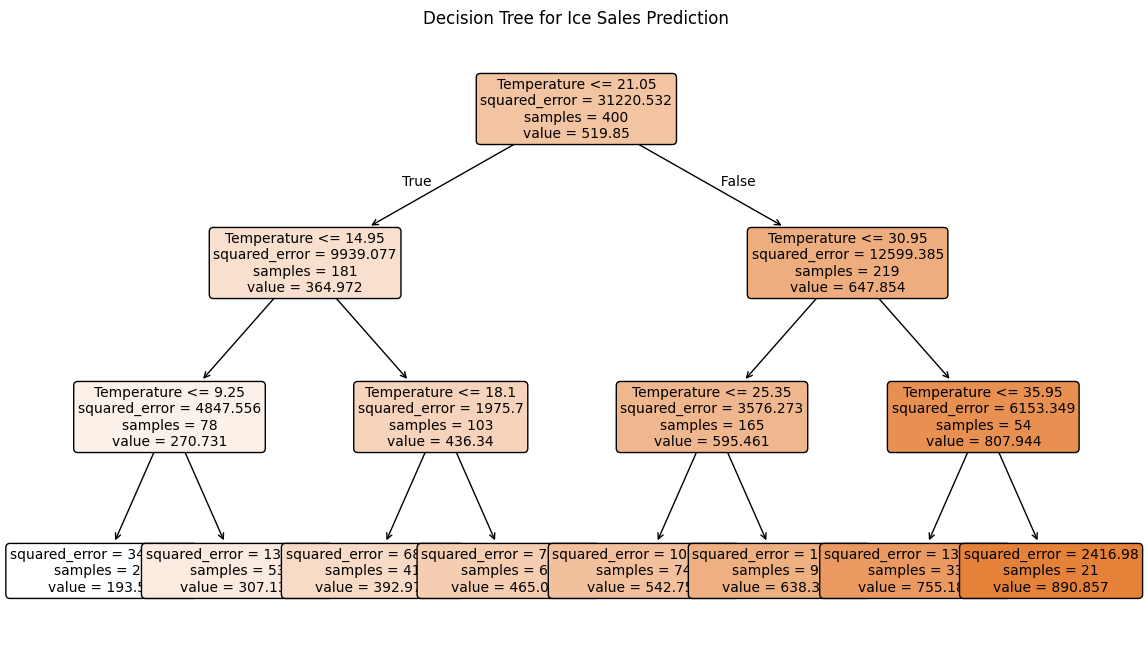

In [16]:
plt.figure(figsize=(14, 8))
plot_tree(dt, feature_names=['Temperature'], filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree for Ice Sales Prediction")
plt.show()
